Dataset Overview:
            Total Images        mean  min  max  Classes
Split                                                  
Test               23472  173.866667   47  320      135
Training           47219  349.770370   96  648      135
Validation         23615  174.925926   48  324      135


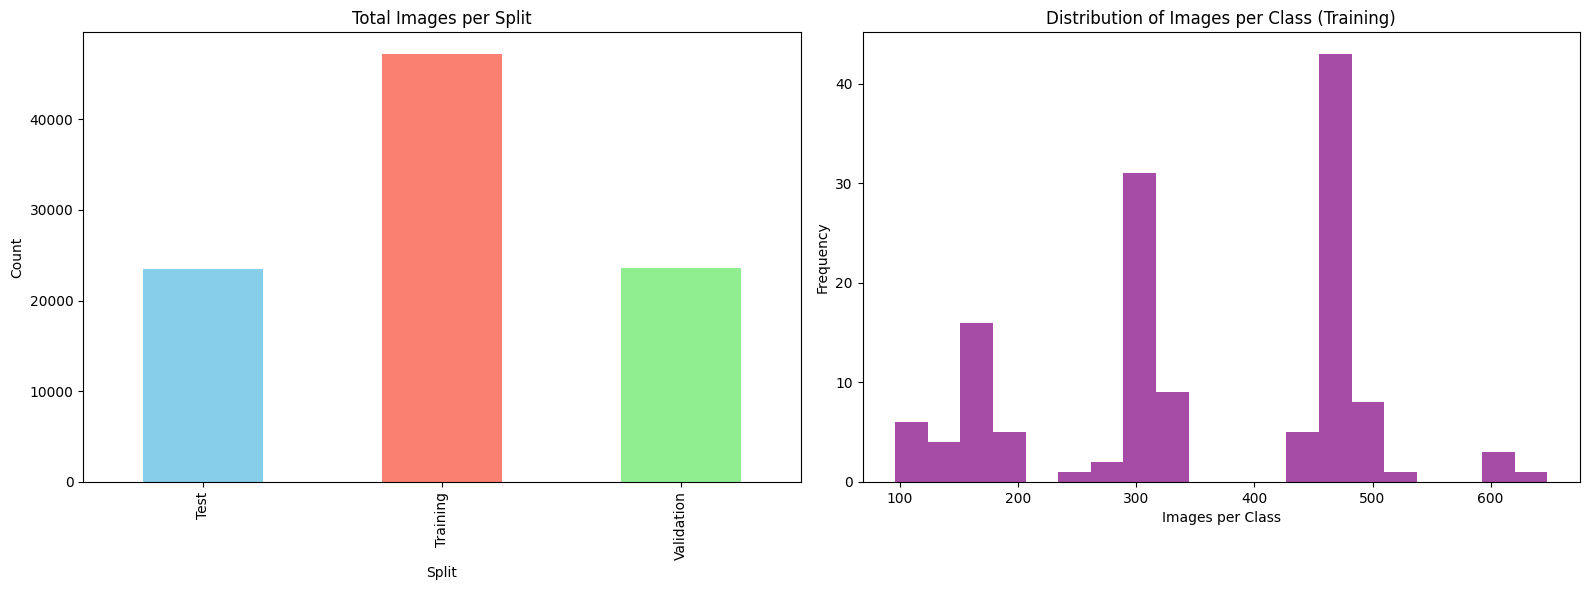


Top 5 Classes (Training):
   Category  Count
Cherimoya 1    648
     Pear 9    620
    Peach 3    618
 Cucumber 6    618
    Onion 2    510

Bottom 5 Classes (Training):
        Category  Count
        Carrot 1    101
      Cucumber 1    100
   Cabbage red 1     99
Zucchini Green 1     96
 cabbage_white_1     96


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
base_path = Path("data/fruits-360")
splits = ["Training", "Validation", "Test"]

data = []

for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue
        
    categories = [d for d in split_path.iterdir() if d.is_dir()]
    
    for category_path in categories:
        category_name = category_path.name
        file_count = len(list(category_path.glob("*.jpg")))
        data.append({
            "Split": split,
            "Category": category_name,
            "Count": file_count
        })

df = pd.DataFrame(data)

# Summary Statistics
stats = df.groupby("Split")["Count"].agg(["sum", "mean", "min", "max", "count"]).rename(columns={"count": "Classes", "sum": "Total Images"})
print("Dataset Overview:")
print(stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Total Images per Split
df.groupby("Split")["Count"].sum().plot(kind="bar", ax=axes[0], color=['skyblue', 'salmon', 'lightgreen'])
axes[0].set_title("Total Images per Split")
axes[0].set_ylabel("Count")

# 2. Distribution of images per class (Training split)
train_df = df[df["Split"] == "Training"].sort_values("Count", ascending=False)
axes[1].hist(train_df["Count"], bins=20, color='purple', alpha=0.7)
axes[1].set_title("Distribution of Images per Class (Training)")
axes[1].set_xlabel("Images per Class")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print top/bottom classes to check for imbalance
print("\nTop 5 Classes (Training):")
print(train_df.head(5)[["Category", "Count"]].to_string(index=False))

print("\nBottom 5 Classes (Training):")
print(train_df.tail(5)[["Category", "Count"]].to_string(index=False))

In [3]:
import os
import pandas as pd
from pathlib import Path

base_path = Path("data/fruits-360")
splits = ["Training", "Validation", "Test"]
# Support multiple image extensions just in case
extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

for split in splits:
    split_path = base_path / split
    if not split_path.exists():
        continue
    
    # Get all subdirectories (categories)
    categories = sorted([d for d in split_path.iterdir() if d.is_dir()])
    
    for cat_path in categories:
        # Count files by checking if suffix is in our extensions set
        files = [f for f in cat_path.iterdir() if f.suffix.lower() in extensions]
        data.append({
            "Category": cat_path.name,
            "Split": split,
            "Count": len(files)
        })

df = pd.DataFrame(data)

# Create a pivot table for an alphabetical overview of all categories
pivot_df = df.pivot(index="Category", columns="Split", values="Count").fillna(0).astype(int)
pivot_df = pivot_df.sort_index() # Alphabetical sort

# Add a total column for the class
pivot_df["Total_Per_Class"] = pivot_df.sum(axis=1)

print(f"Total Images in Dataset: {pivot_df['Total_Per_Class'].sum()}")
print(f"Unique Categories: {len(pivot_df)}")
print("-" * 30)

# Display the full table (Jupyter will provide a scrollable view)
pd.set_option('display.max_rows', None)
display(pivot_df)

Total Images in Dataset: 94306
Unique Categories: 137
------------------------------


Split,Test,Training,Validation,Total_Per_Class
Category,,,,
Almonds 1,77,155,77,309
Apple 10,231,465,234,930
Apple 11,142,287,143,572
Apple 12,154,310,156,620
Apple 13,231,465,234,930
Apple 14,154,310,156,620
Apple 17,243,489,243,975
Apple 18,242,486,242,970
Apple 19,241,486,243,970


In [4]:
# find Unit_0/data/fruits-360 -type f \( -iname "*.jpg" -o -iname "*.jpeg" -o -iname "*.png" \) | wc -l
# Call in terminal e.g.

In [5]:
import pandas as pd

# 1. Create mapping: Use first word, handle both spaces and underscores, normalize case
# pivot_df is assumed to be the dataframe from the previous cell
pivot_df['Super_Category'] = pivot_df.index.str.split(r'[ _]').str[0].str.capitalize()

# 2. Aggregate counts by the new Super-Category
super_cat_stats = pivot_df.groupby('Super_Category').agg({
    'Training': 'sum',
    'Validation': 'sum',
    'Test': 'sum',
    'Total_Per_Class': 'sum'
})

# 3. Add a count of how many sub-variants (original folders) belong to each Super-Category
super_cat_stats['Sub_Variant_Count'] = pivot_df.groupby('Super_Category').size()

# 4. Sort by total volume
super_cat_stats = super_cat_stats.sort_values("Total_Per_Class", ascending=False)

# Display results
print(f"Total Super-Categories: {len(super_cat_stats)}")
print("-" * 30)
display(super_cat_stats)

# Summary of the top 5 largest groups
print("\nTop 5 Super-Categories by Image Volume:")
print(super_cat_stats.head(5).to_string())

Total Super-Categories: 33
------------------------------


Split,Training,Validation,Test,Total_Per_Class,Sub_Variant_Count
Super_Category,,,,,
Apple,11028,5515,5492,22035,31
Pear,5157,2575,2560,10292,13
Tomato,3873,1935,1922,7730,11
Cherry,3825,1913,1900,7638,10
Cucumber,3549,1777,1765,7091,10
Pepper,2509,1255,1248,5012,7
Peach,2055,1026,1023,4104,4
Blackberry,1505,753,751,3009,5
Quince,1474,736,731,2941,3



Top 5 Super-Categories by Image Volume:
Split           Training  Validation  Test  Total_Per_Class  Sub_Variant_Count
Super_Category                                                                
Apple              11028        5515  5492            22035                 31
Pear                5157        2575  2560            10292                 13
Tomato              3873        1935  1922             7730                 11
Cherry              3825        1913  1900             7638                 10
Cucumber            3549        1777  1765             7091                 10


In [6]:
# Group by Super_Category and collect all original index names (sub-variants)
sub_variant_lists = pivot_df.groupby('Super_Category').apply(
    lambda x: ", ".join(sorted(x.index.tolist()))
).rename("Sub_Variants")

# Join this list back to your super_cat_stats dataframe
detailed_super_cat = super_cat_stats.join(sub_variant_lists)

# Display the full table
pd.set_option('display.max_colwidth', None)  # Ensure we see all names
display(detailed_super_cat)

# Specific check for 'Apple' to verify your 31 variants
print("\nDetailed breakdown for 'Apple':")
apple_info = detailed_super_cat.loc[['Apple']]
print(f"Total Folders: {apple_info['Sub_Variant_Count'].values[0]}")
print(f"Variants: {apple_info['Sub_Variants'].values[0]}")

,Training,Validation,Test,Total_Per_Class,Sub_Variant_Count,Sub_Variants
Super_Category,,,,,,
Apple,11028,5515,5492,22035,31,"Apple 10, Apple 11, Apple 12, Apple 13, Apple 14, Apple 17, Apple 18, Apple 19, Apple 20, Apple 21, Apple 22, Apple 23, Apple 5, Apple 6, Apple 7, Apple 8, Apple 9, Apple Braeburn 1, Apple Red Yellow 2, apple_braeburn_1, apple_crimson_snow_1, apple_golden_1, apple_golden_2, apple_golden_3, apple_granny_smith_1, apple_pink_lady_1, apple_red_1, apple_red_2, apple_red_3, apple_red_delicios_1, apple_red_yellow_1"
Pear,5157,2575,2560,10292,13,"Pear 1, Pear 10, Pear 11, Pear 12, Pear 13, Pear 14, Pear 3, Pear 5, Pear 6, Pear 7, Pear 8, Pear 9, Pear common 1"
Tomato,3873,1935,1922,7730,11,"Tomato 1, Tomato 10, Tomato 5, Tomato 7, Tomato 8, Tomato 9, Tomato Cherry Maroon 1, Tomato Cherry Orange 1, Tomato Cherry Red 2, Tomato Cherry Yellow 1, Tomato Maroon 2"
Cherry,3825,1913,1900,7638,10,"Cherry 3, Cherry 4, Cherry 5, Cherry Rainier 2, Cherry Rainier 3, Cherry Sour 1, Cherry Wax 1, Cherry Wax 2, Cherry Wax Red 2, Cherry Wax Red 3"
Cucumber,3549,1777,1765,7091,10,"Cucumber 1, Cucumber 10, Cucumber 11, Cucumber 3, Cucumber 4, Cucumber 5, Cucumber 6, Cucumber 7, Cucumber 8, Cucumber 9"
Pepper,2509,1255,1248,5012,7,"Pepper 1, Pepper 2, Pepper Orange 2, Pepper Red 2, Pepper Red 3, Pepper Red 4, Pepper Red 5"
Peach,2055,1026,1023,4104,4,"Peach 3, Peach 4, Peach 5, Peach 6"
Blackberry,1505,753,751,3009,5,"Blackberry 1, Blackberry 2, Blackberry 3, Blackberry 4, Blackberry 5"
Quince,1474,736,731,2941,3,"Quince 2, Quince 3, Quince 4"



Detailed breakdown for 'Apple':
Total Folders: 31
Variants: Apple 10, Apple 11, Apple 12, Apple 13, Apple 14, Apple 17, Apple 18, Apple 19, Apple 20, Apple 21, Apple 22, Apple 23, Apple 5, Apple 6, Apple 7, Apple 8, Apple 9, Apple Braeburn 1, Apple Red Yellow 2, apple_braeburn_1, apple_crimson_snow_1, apple_golden_1, apple_golden_2, apple_golden_3, apple_granny_smith_1, apple_pink_lady_1, apple_red_1, apple_red_2, apple_red_3, apple_red_delicios_1, apple_red_yellow_1


In [7]:
import matplotlib.pyplot as plt
import PIL.Image as Image
import random
from pathlib import Path

def inspect_category(category_name, base_path="data/fruits-360"):
    base = Path(base_path)
    splits = ["Training", "Validation", "Test"]
    
    # 1. Print Folder Statistics
    print(f"Inspection for Category: {category_name}")
    print("-" * 30)
    
    split_files = {}
    for s in splits:
        p = base / s / category_name
        files = list(p.glob("*.jpg")) + list(p.glob("*.png"))
        split_files[s] = files
        print(f"{s.ljust(12)}: {len(files)} images")
    
    # 2. Prepare Sampling (Prioritizing Training for display)
    all_images = split_files["Training"] if split_files["Training"] else split_files["Test"]
    
    if len(all_images) < 9:
        print(f"\nWarning: Not enough images to show 3x3 grid (found {len(all_images)})")
        return

    sample_paths = random.sample(all_images, 9)
    
    # 3. Plot 3x3 Grid
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle(f"Random Samples from {category_name} (Training)", fontsize=16)
    
    for i, ax in enumerate(axes.flat):
        img = Image.open(sample_paths[i])
        ax.imshow(img)
        ax.set_title(f"Size: {img.size}")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

Inspection for Category: Apple 10
------------------------------
Training    : 465 images
Validation  : 234 images
Test        : 231 images


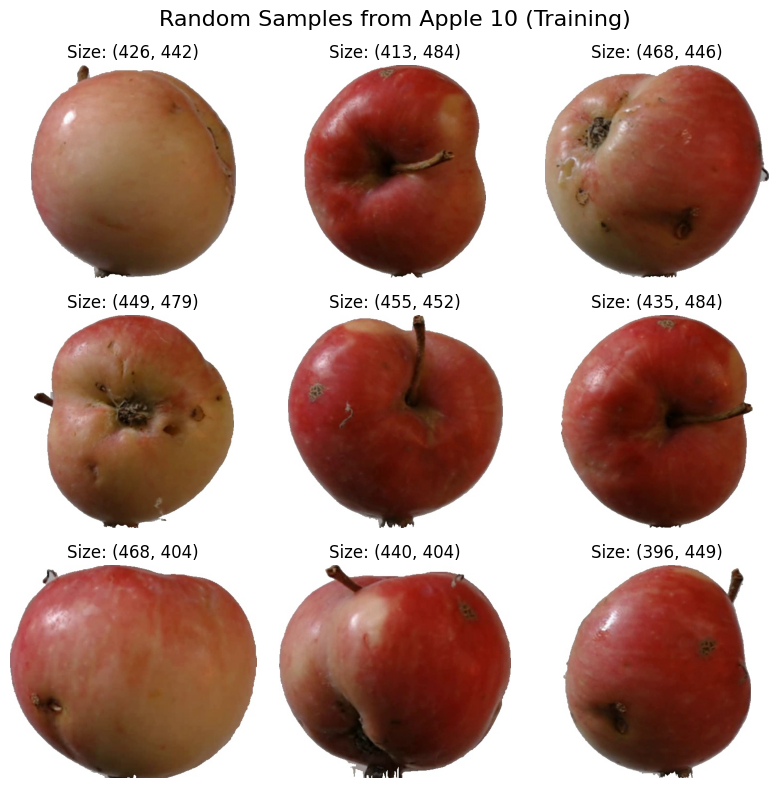

In [8]:
# Usage
inspect_category("Apple 10")

Inspection for Category: Papaya 2
------------------------------
Training    : 483 images
Validation  : 242 images
Test        : 240 images


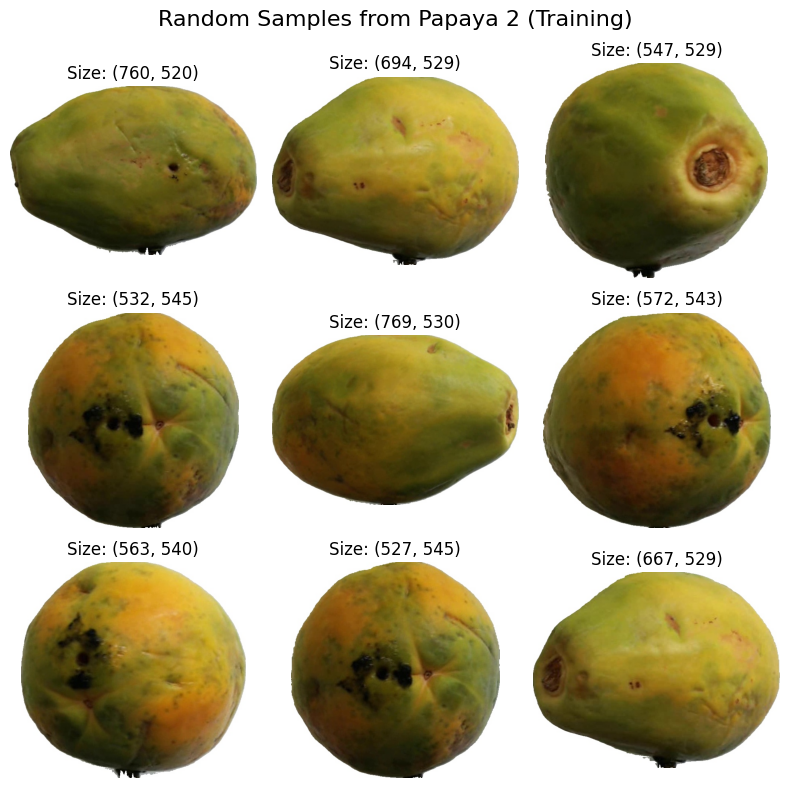

In [12]:
# Usage
inspect_category("Papaya 2")